In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# loading our best model and data
with open('../outputs/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open('../outputs/X_test_final.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('../outputs/y_test_final.pkl', 'rb') as f:
    y_test = pickle.load(f)

with open('../outputs/feature_names_final.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("All files loaded!")
print(f"Test rows: {len(X_test)}")
print(f"Features: {len(feature_names)}")

All files loaded!
Test rows: 36104
Features: 113


In [2]:
# getting probability of late delivery for each order
risk_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"Sample probabilities:")
print(risk_prob[:10].round(3))
print(f"\nMin probability: {risk_prob.min():.3f}")
print(f"Max probability: {risk_prob.max():.3f}")
print(f"Mean probability: {risk_prob.mean():.3f}")

Sample probabilities:
[0.367 0.46  0.278 0.413 0.498 0.501 0.998 0.389 0.316 0.315]

Min probability: 0.115
Max probability: 0.998
Mean probability: 0.548


In [3]:
# assigning risk category based on probability
def assign_risk(prob):
    if prob < 0.4:
        return 'Low Risk'
    elif prob < 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'

# creating results dataframe
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Late_Probability': risk_prob.round(3),
    'Risk_Category': [assign_risk(p) for p in risk_prob]
})

print("Risk category distribution:")
print(results_df['Risk_Category'].value_counts())

Risk category distribution:
Risk_Category
Low Risk       14970
High Risk      12584
Medium Risk     8550
Name: count, dtype: int64


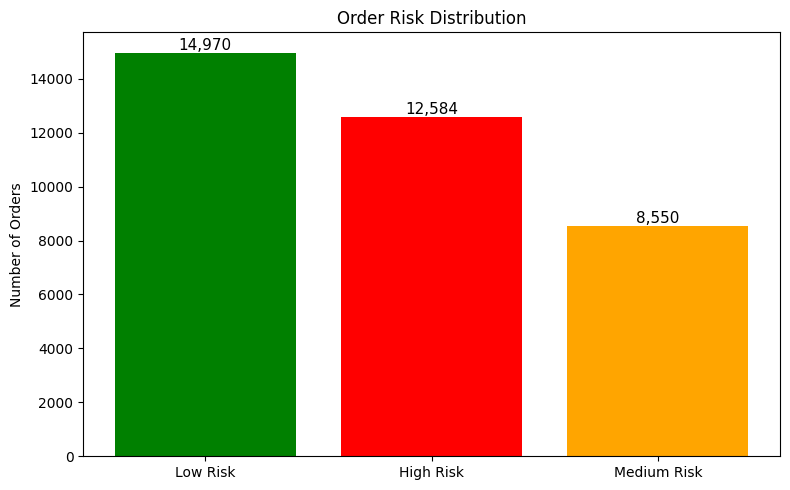

In [4]:
# visualizing risk distribution
colors = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}
risk_counts = results_df['Risk_Category'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(risk_counts.index, risk_counts.values,
               color=[colors[x] for x in risk_counts.index])

# adding count labels on bars
for bar, count in zip(bars, risk_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{count:,}', ha='center', fontsize=11)

plt.title('Order Risk Distribution')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../outputs/risk_distribution.png')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_6444\1301136034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Reds_r')


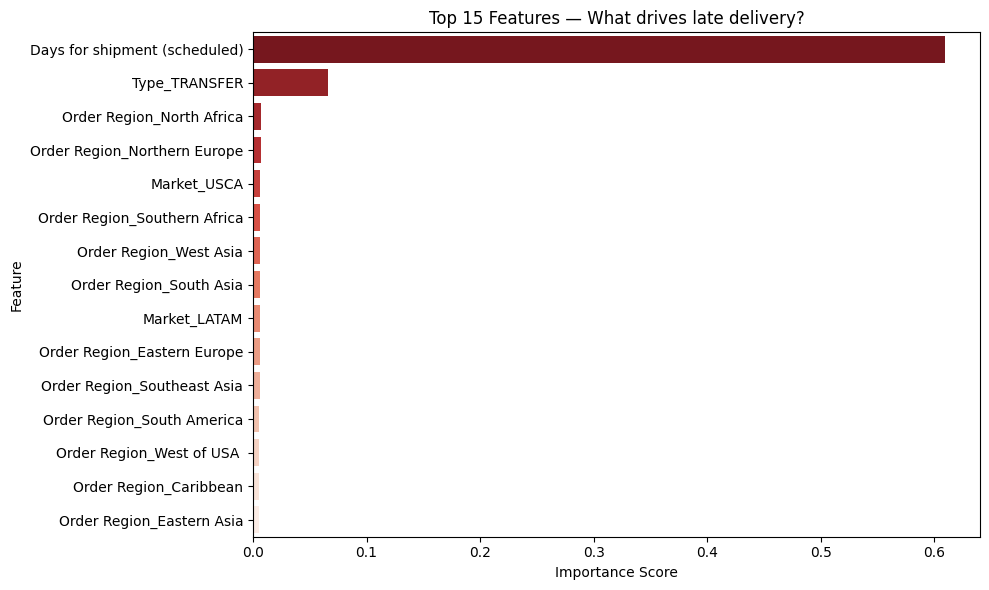


Top 10 features:
                      Feature  Importance
Days for shipment (scheduled)    0.609592
                Type_TRANSFER    0.066063
    Order Region_North Africa    0.007077
 Order Region_Northern Europe    0.006678
                  Market_USCA    0.006362
 Order Region_Southern Africa    0.006119
       Order Region_West Asia    0.006074
      Order Region_South Asia    0.006030
                 Market_LATAM    0.005965
  Order Region_Eastern Europe    0.005932


In [5]:
# which features matter most for prediction
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Reds_r')
plt.title('Top 15 Features — What drives late delivery?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

In [6]:
# saving final risk scores for dashboard use
results_df.to_csv('../outputs/risk_scores.csv', index=False)
print("Risk scores saved!")
print(f"\nSample output:")
print(results_df.head(10).to_string(index=False))


Risk scores saved!

Sample output:
 Actual  Late_Probability Risk_Category
      0             0.367      Low Risk
      0             0.460   Medium Risk
      0             0.278      Low Risk
      1             0.413   Medium Risk
      0             0.498   Medium Risk
      0             0.501   Medium Risk
      1             0.998     High Risk
      0             0.389      Low Risk
      1             0.316      Low Risk
      0             0.315      Low Risk


In [7]:
# orders that need immediate attention
high_risk = results_df[results_df['Risk_Category'] == 'High Risk'].copy()
high_risk = high_risk.sort_values('Late_Probability', ascending=False)

print(f"Total High Risk Orders: {len(high_risk)}")
print(f"\nTop 10 highest risk orders:")
print(high_risk.head(10).to_string(index=False))

high_risk.to_csv('../outputs/high_risk_orders.csv', index=False)
print("\nHigh risk orders saved!")

Total High Risk Orders: 12584

Top 10 highest risk orders:
 Actual  Late_Probability Risk_Category
      1             0.998     High Risk
      1             0.998     High Risk
      1             0.998     High Risk
      1             0.998     High Risk
      1             0.998     High Risk
      1             0.998     High Risk
      1             0.998     High Risk
      1             0.998     High Risk
      1             0.998     High Risk
      1             0.998     High Risk

High risk orders saved!
